In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [4]:
transactions = pd.read_csv("D:\Dataset\Internship Fraud Detection\paysim_transactions.csv", 
                          parse_dates=['timestamp'])
customers = pd.read_csv("D:\Dataset\Internship Fraud Detection\customers.csv")
fraud_cases = pd.read_csv(r"D:\Dataset\Internship Fraud Detection\fraud_cases.csv")
alerts = pd.read_csv(r"D:\Dataset\Internship Fraud Detection\alerts.csv", parse_dates=['timestamp'])

In [17]:
customers.head()

,customer_id,segment,account_age_days,risk_score,email_verified,phone_verified,avg_monthly_transactions,avg_transaction_amount,device_count,location
0,CUST_000000,Retail,2332,0.697657,True,True,45,2064.757168,3,US
1,CUST_000001,Retail,531,0.588541,True,True,83,3040.637196,4,IN
2,CUST_000002,Business,1974,0.364320,True,True,9,2079.751870,1,US
3,CUST_000003,Retail,1852,0.454465,True,True,94,1135.531920,3,IN
4,CUST_000004,Business,2185,0.631022,False,True,94,3991.774005,2,IN


In [6]:
print("Initial Data Shapes:")
print(f"Transactions: {transactions.shape}")
print(f"Customers: {customers.shape}")
print(f"Fraud Cases: {fraud_cases.shape}")
print(f"Alerts: {alerts.shape}")

Initial Data Shapes:
Transactions: (100000, 14)
Customers: (10000, 10)
Fraud Cases: (1955, 8)
Alerts: (5000, 7)


In [7]:
print("\nMissing Values:")
print(transactions.isnull().sum())
print(customers.isnull().sum())


Missing Values:
transaction_id       0
customer_id          0
amount               0
timestamp            0
hour                 0
day_of_week          0
location             0
merchant_category    0
is_new_device        0
device_id            0
ip_address           0
is_fraud             0
transaction_type     0
card_present         0
dtype: int64
customer_id                 0
segment                     0
account_age_days            0
risk_score                  0
email_verified              0
phone_verified              0
avg_monthly_transactions    0
avg_transaction_amount      0
device_count                0
location                    0
dtype: int64


In [8]:
def clean_transactions(df):
    """Clean transaction data"""
    df_clean = df.copy()
    
    # Remove duplicates
    df_clean = df_clean.drop_duplicates(subset=['transaction_id'])
    
    # Handle missing values
    df_clean['merchant_category'] = df_clean['merchant_category'].fillna('Unknown')
    df_clean['device_id'] = df_clean['device_id'].fillna('UNKNOWN')
    
    # Remove outliers (amount > 3 std from mean)
    mean_amount = df_clean['amount'].mean()
    std_amount = df_clean['amount'].std()
    df_clean = df_clean[df_clean['amount'] <= mean_amount + 3*std_amount]
    
    # Create additional features
    df_clean['amount_log'] = np.log1p(df_clean['amount'])
    df_clean['is_weekend'] = df_clean['day_of_week'].isin([5, 6]).astype(int)
    
    return df_clean

In [9]:
def clean_customers(df):
    """Clean customer data"""
    df_clean = df.copy()
    
    # Handle missing values
    df_clean['risk_score'] = df_clean['risk_score'].fillna(0.5)
    df_clean['avg_monthly_transactions'] = df_clean['avg_monthly_transactions'].fillna(10)
    df_clean['avg_transaction_amount'] = df_clean['avg_transaction_amount'].fillna(100)
    
    return df_clean


In [10]:
transactions_clean = clean_transactions(transactions)
customers_clean = clean_customers(customers)


In [11]:
print(f"\nAfter Cleaning:")
print(f"Transactions: {transactions_clean.shape}")
print(f"Customers: {customers_clean.shape}")


After Cleaning:
Transactions: (99106, 16)
Customers: (10000, 10)


In [12]:
transactions_clean.to_csv('D:\Dataset\Internship Fraud Detection\paysim_transactions_cleaned.csv', index=False)
customers_clean.to_csv('D:\Dataset\Internship Fraud Detection\customers_cleaned.csv', index=False)

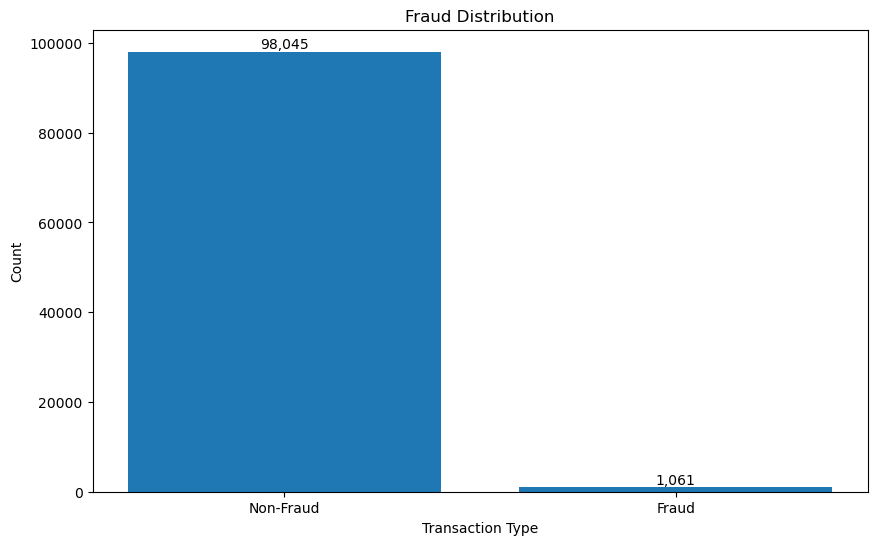

Fraud Rate: 1.07%


In [13]:
plt.figure(figsize=(10, 6))
fraud_counts = transactions_clean['is_fraud'].value_counts()
plt.bar(['Non-Fraud', 'Fraud'], fraud_counts.values)
plt.title('Fraud Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.text(0, fraud_counts[0], f'{fraud_counts[0]:,}', ha='center', va='bottom')
plt.text(1, fraud_counts[1], f'{fraud_counts[1]:,}', ha='center', va='bottom')
plt.show()

print(f"Fraud Rate: {fraud_counts[1] / len(transactions_clean) * 100:.2f}%")